<a href="https://colab.research.google.com/github/Karthik5412/Deep-Learning-Projects/blob/main/CNN/animals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Download the 10 Animals dataset
!kaggle datasets download -d alessiocorrado99/animals10

# Unzip it quietly (-q) into a dedicated folder
!unzip -q animals10.zip -d ./wild_animals

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
animals10.zip: Skipping, found more recently modified local copy (use --force to force download)
replace ./wild_animals/raw-img/cane/OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./wild_animals/raw-img/cane/OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./wild_animals/raw-img/cane/OIP---ZIdwfUcJeVxnh47zppcQHaFj.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./wild_animals/raw-img/cane/OIP---ZRsOF7zsMqhW30WeF8-AHaFj.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./wild_animals/raw-img/cane/OIP---_cJbI6Ei26w5bW1urHewHaCf.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./wild_animals/raw-img/cane/OIP---cByAiEbIxIAleGo9AqOQAAAA.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./wild_animals/raw-img/cane/OIP--0C2kq6I68beB3DduLoxMgHaEf.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./wild_animals/r

In [2]:
import os

dataset_path = "./wild_animals/raw-img"

if os.path.exists(dataset_path):
    animal_folders = os.listdir(dataset_path)
    print(f"📊 Success! Found {len(animal_folders)} animal classes.")
    print("Your directories:")
    for folder in animal_folders:
        # Count how many images are in each folder
        num_images = len(os.listdir(os.path.join(dataset_path, folder)))
        print(f"  • {folder}: {num_images} images")
else:
    print("Could not find the path. Run a quick !ls to check where it unzipped!")

📊 Success! Found 10 animal classes.
Your directories:
  • cavallo: 2623 images
  • elefante: 1446 images
  • cane: 4863 images
  • ragno: 4821 images
  • farfalla: 2112 images
  • pecora: 1820 images
  • mucca: 1866 images
  • scoiattolo: 1862 images
  • gallina: 3098 images
  • gatto: 1668 images


In [3]:
translate = {
    "cane": "dog", "cavallo": "horse", "elefante": "elephant",
    "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat",
    "mucca": "cow", "pecora": "sheep", "scoiattolo": "squirrel",
    "ragno": "spider"
}

# **My Code From Here**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [5]:
train_ds = image_dataset_from_directory("/content/wild_animals/raw-img",labels='inferred',label_mode='int', color_mode='rgb',image_size=(256,256), shuffle=True,validation_split=0.2 ,seed=123,subset='training')

val_ds = image_dataset_from_directory("/content/wild_animals/raw-img",labels='inferred',label_mode='int', color_mode='rgb',image_size=(256,256), shuffle=True, validation_split=0.2,seed=123,subset='validation')

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.


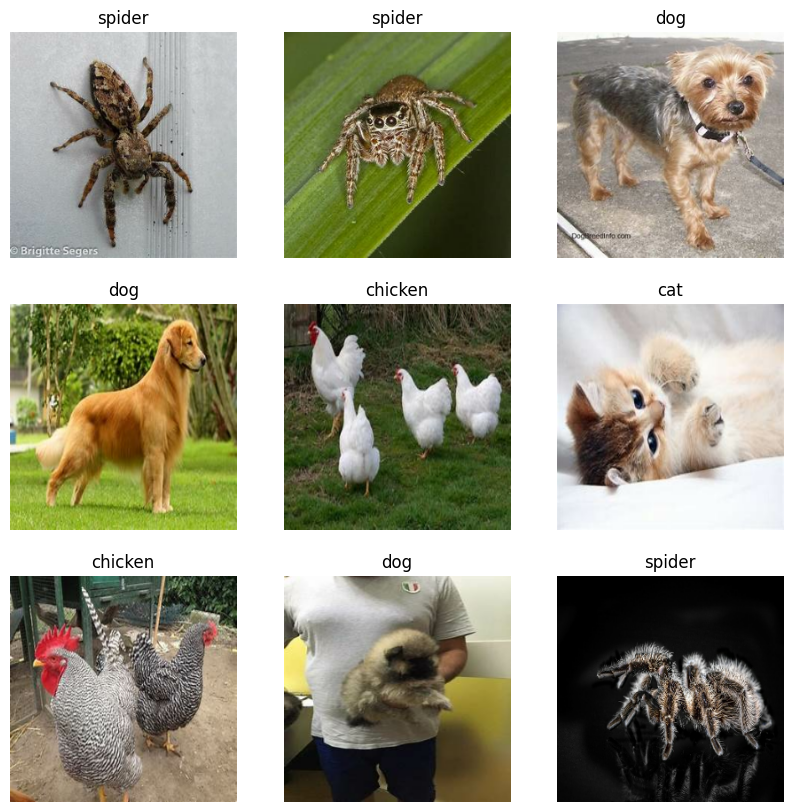

In [6]:
plt.figure(figsize=(10,10))

class_names = train_ds.class_names

for img,label in train_ds.take(12):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(translate[class_names[label[i]]])
        plt.axis('off')

plt.show()

In [7]:
train_ds.class_names = ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']

train_ds.class_names

['dog',
 'horse',
 'elephant',
 'butterfly',
 'chicken',
 'cat',
 'cow',
 'sheep',
 'spider',
 'squirrel']

In [8]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Dropout, InputLayer,Rescaling, Flatten, GlobalAveragePooling2D
from tensorflow.keras import Sequential

In [14]:
cnn = Sequential([
    InputLayer(shape=(255,255,3), batch_size= 16),
    Rescaling(1./255),
    Conv2D(32,kernel_size=(3,3), activation='relu'),
    MaxPool2D(2,2),
    Conv2D(64,kernel_size=(3,3), activation='relu'),
    MaxPool2D(2,2),
    Conv2D(128,kernel_size=(3,3), activation='relu'),
    MaxPool2D(2,2),
    Conv2D(256,kernel_size=(3,3), activation='relu'),
    MaxPool2D(2,2),
    GlobalAveragePooling2D(),
    Dense(256,activation='relu'),
    Dropout(0.2),
    Dense(128,activation='relu'),
    Dropout(0.2),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(10,activation='softmax')
])

In [15]:
from tensorflow.keras import optimizers

adam = optimizers.Adam(learning_rate = 0.0001)

In [16]:
cnn.compile(optimizer=adam, loss= 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [17]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (16, 255, 255, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (16, 253, 253, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (16, 126, 126, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (16, 124, 124, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (16, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (16, 60, 60, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (16, 30, 30, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (16, 28, 28, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (16, 14, 14, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (16, 256)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (16, 256)              │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (16, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (16, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (16, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (16, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (16, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (16, 10)               │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 496,010 (1.89 MB)

 Trainable params: 496,010 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = cnn.fit(train_ds,batch_size= 32, epochs= 50, verbose=1, validation_split=0.2, validation_data= val_ds, validation_batch_size= 32)

Epoch 1/50
298/655 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step - accuracy: 0.1432 - loss: 2.2701